# 04 — Disease–Perturbation Anticorrelation and Target Prioritization

This notebook is the final **publication-style anticorrelation analysis** for the project:

**`multiomics-perturbation-target-discovery`**

## Goal

We compare the **ulcerative colitis (UC) disease pathway signature** against curated **LINCS-style perturbation pathway signatures** and rank perturbations by how strongly they **reverse** disease-associated pathway activity.

## Biological rationale

A perturbation is desirable when it pushes pathways in the **opposite direction** of disease:

- disease pathway **up** + perturbation pathway **down** → potential reversal
- disease pathway **down** + perturbation pathway **up** → potential reversal

Therefore, **negative correlation** between disease NES and perturbation NES is interpreted as a favorable reversal pattern.

## Expected inputs

This notebook expects outputs already generated in earlier steps:

- `results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv`
- `results/tables/lincs_perturbation_pathway_signatures_long.tsv`
- optionally: `results/tables/lincs_disease_perturbation_pathway_alignment.tsv`

## Main outputs

- `results/tables/final_anticorrelation_ranking.tsv`
- `results/tables/final_anticorrelation_per_pathway_details.tsv`
- publication-style figures saved under `results/figures/`

## Analysis design

For each perturbation, we compute:

1. **Shared pathway overlap** with the disease signature
2. **Pearson correlation** between disease NES and perturbation NES
3. **Spearman correlation** between disease NES and perturbation NES
4. **Directional reversal fraction**  
   Fraction of shared pathways where disease and perturbation move in opposite directions
5. **Weighted reversal strength**  
   A pathway-level score based on the signed product of disease NES and perturbation NES, optionally weighted by pathway significance

### Interpretation

- **More negative correlation** → better global reversal
- **More shared pathways** → more reliable comparison
- **Higher reversal fraction** → more pathways moving in the desired opposite direction
- **Higher weighted reversal strength** → stronger magnitude-consistent reversal

This notebook keeps the scoring framework transparent and easy to explain in a portfolio or manuscript-style setting.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

disease_file = TABLES_DIR / "GSE235236_UC_vs_HC_disease_pathway_signature.tsv"
perturb_long_file = TABLES_DIR / "lincs_perturbation_pathway_signatures_long.tsv"
alignment_file = TABLES_DIR / "lincs_disease_perturbation_pathway_alignment.tsv"

print("Disease file:", disease_file)
print("Perturbation long file:", perturb_long_file)
print("Alignment file:", alignment_file)

Disease file: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/GSE235236_UC_vs_HC_disease_pathway_signature.tsv
Perturbation long file: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/lincs_perturbation_pathway_signatures_long.tsv
Alignment file: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/lincs_disease_perturbation_pathway_alignment.tsv


## 1. Load and standardize inputs

The code below is robust to either of the following situations:

- a precomputed alignment file already exists
- only disease and perturbation pathway tables exist, so alignment must be reconstructed

In [2]:

def _find_first_column(df, candidates, required=True):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Could not find any of {candidates} in columns: {list(df.columns)}")
    return None


def _clean_pathway_series(s):
    s = s.astype(str).str.strip()
    s = s.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return s


def load_disease_signature(path):
    if not path.exists():
        raise FileNotFoundError(f"Disease pathway signature not found: {path}")
    df = pd.read_csv(path, sep="\t")
    pathway_col = _find_first_column(df, ["Pathway", "pathway", "Term"])
    nes_col = _find_first_column(df, ["NES", "nes"])
    fdr_col = _find_first_column(df, ["FDR", "fdr", "padj", "adj_pval"], required=False)

    out = df.rename(columns={
        pathway_col: "Pathway",
        nes_col: "disease_NES",
        fdr_col if fdr_col else pathway_col: fdr_col if fdr_col else pathway_col
    }).copy()

    if fdr_col:
        out = out.rename(columns={fdr_col: "disease_FDR"})
    else:
        out["disease_FDR"] = np.nan

    out = out[["Pathway", "disease_NES", "disease_FDR"]].copy()
    out["Pathway"] = _clean_pathway_series(out["Pathway"])
    out = out.dropna(subset=["Pathway", "disease_NES"]).drop_duplicates(subset=["Pathway"]).reset_index(drop=True)
    return out


def load_perturbation_long(path):
    if not path.exists():
        raise FileNotFoundError(f"Perturbation pathway signature file not found: {path}")
    df = pd.read_csv(path, sep="\t")
    pathway_col = _find_first_column(df, ["Pathway", "pathway", "Term"])
    nes_col = _find_first_column(df, ["NES", "nes"])
    fdr_col = _find_first_column(df, ["FDR", "fdr", "padj", "adj_pval"], required=False)

    required_meta = ["perturbation_id", "perturbation_name"]
    missing_meta = [c for c in required_meta if c not in df.columns]
    if missing_meta:
        raise KeyError(f"Missing required perturbation metadata columns: {missing_meta}")

    out = df.rename(columns={
        pathway_col: "Pathway",
        nes_col: "perturbation_NES",
    }).copy()

    if fdr_col:
        out = out.rename(columns={fdr_col: "perturbation_FDR"})
    else:
        out["perturbation_FDR"] = np.nan

    keep_cols = [c for c in [
        "Pathway",
        "perturbation_NES",
        "perturbation_FDR",
        "perturbation_id",
        "perturbation_name",
        "cell_line",
        "dose",
        "time_h",
        "signature_source",
    ] if c in out.columns]

    out = out[keep_cols].copy()
    out["Pathway"] = _clean_pathway_series(out["Pathway"])
    out = out.dropna(subset=["Pathway", "perturbation_NES"]).drop_duplicates(subset=["perturbation_id", "Pathway"]).reset_index(drop=True)
    return out


def load_or_build_alignment(disease_path, perturb_long_path, alignment_path):
    disease_df = load_disease_signature(disease_path)

    if alignment_path.exists():
        align = pd.read_csv(alignment_path, sep="\t")
        pathway_col = _find_first_column(align, ["Pathway", "pathway", "Term"])
        align = align.rename(columns={pathway_col: "Pathway"}).copy()
        align["Pathway"] = _clean_pathway_series(align["Pathway"])

        # Standardize disease NES column names if needed
        if "disease_NES" not in align.columns:
            disease_nes_alt = _find_first_column(align, ["disease_NES", "NES_disease", "disease_nes"], required=False)
            if disease_nes_alt:
                align = align.rename(columns={disease_nes_alt: "disease_NES"})
        if "perturbation_NES" not in align.columns:
            pert_nes_alt = _find_first_column(align, ["perturbation_NES", "NES", "perturbation_nes"], required=False)
            if pert_nes_alt:
                align = align.rename(columns={pert_nes_alt: "perturbation_NES"})

        # standardize perturbation FDR if needed
        if "perturbation_FDR" not in align.columns:
            fdr_alt = _find_first_column(align, ["perturbation_FDR", "fdr", "FDR_perturbation"], required=False)
            if fdr_alt:
                align = align.rename(columns={fdr_alt: "perturbation_FDR"})
            else:
                align["perturbation_FDR"] = np.nan

        # join disease-side columns if not already present
        if "disease_FDR" not in align.columns:
            align = align.merge(disease_df[["Pathway", "disease_FDR"]], on="Pathway", how="left")

        if "disease_NES" not in align.columns:
            align = align.merge(disease_df[["Pathway", "disease_NES"]], on="Pathway", how="left")

        # guard against old broken alignment files where Pathway was numeric index rather than name
        disease_match_fraction = align["Pathway"].isin(set(disease_df["Pathway"])).mean() if len(align) else 0
        if disease_match_fraction < 0.2:
            print("Warning: existing alignment file appears inconsistent with current disease pathway names.")
            print("Rebuilding alignment from perturbation long table instead of using the saved alignment file.")
            perturb_df = load_perturbation_long(perturb_long_path)
            align = perturb_df.merge(disease_df, on="Pathway", how="inner")

        return disease_df, align

    perturb_df = load_perturbation_long(perturb_long_path)
    align = perturb_df.merge(disease_df, on="Pathway", how="inner")
    return disease_df, align


disease_df, alignment_df = load_or_build_alignment(
    disease_file,
    perturb_long_file,
    alignment_file
)

print("Disease pathways:", disease_df.shape)
print("Aligned rows:", alignment_df.shape)
display(disease_df.head())
display(alignment_df.head())


Disease pathways: (50, 3)
Aligned rows: (22, 12)


,Pathway,disease_NES,disease_FDR
0,1,2.018700,0.000000
1,2,1.789889,0.003271
2,3,1.773973,0.002181
3,6,1.747378,0.002617
4,12,1.570056,0.015439


,Pathway,perturbation_NES,FDR,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,disease_NES,perturbation_FDR,disease_FDR
0,0,-2.358761,0.000000,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-2.058361,NaN,0.000000
1,1,-2.001288,0.003420,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,2.018700,NaN,0.000000
2,2,-1.721389,0.023368,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.789889,NaN,0.003271
3,3,-1.698453,0.020519,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.773973,NaN,0.002181
4,4,-1.477493,0.071473,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-1.765320,NaN,0.000000


## 2. Quality checks

We first confirm that the aligned table contains the required information for anticorrelation analysis.

In [3]:
required_cols = ["Pathway", "disease_NES", "perturbation_NES", "perturbation_id", "perturbation_name"]
missing_required = [c for c in required_cols if c not in alignment_df.columns]
if missing_required:
    raise ValueError(f"Alignment table is missing required columns: {missing_required}")

alignment_df = alignment_df.copy()
alignment_df["disease_NES"] = pd.to_numeric(alignment_df["disease_NES"], errors="coerce")
alignment_df["perturbation_NES"] = pd.to_numeric(alignment_df["perturbation_NES"], errors="coerce")

for col in ["disease_FDR", "perturbation_FDR"]:
    if col in alignment_df.columns:
        alignment_df[col] = pd.to_numeric(alignment_df[col], errors="coerce")
    else:
        alignment_df[col] = np.nan

alignment_df = alignment_df.dropna(subset=["Pathway", "disease_NES", "perturbation_NES"]).copy()
alignment_df["shared_direction"] = np.sign(alignment_df["disease_NES"]) == np.sign(alignment_df["perturbation_NES"])
alignment_df["reversal"] = np.sign(alignment_df["disease_NES"]) != np.sign(alignment_df["perturbation_NES"])
alignment_df["abs_disease_NES"] = alignment_df["disease_NES"].abs()
alignment_df["abs_perturbation_NES"] = alignment_df["perturbation_NES"].abs()

print("Unique perturbations:", alignment_df["perturbation_id"].nunique())
print("Shared pathways total:", alignment_df.shape[0])

alignment_df[[
    "Pathway", "perturbation_id", "perturbation_name",
    "disease_NES", "perturbation_NES", "reversal"
]].head()

Unique perturbations: 4
Shared pathways total: 22


,Pathway,perturbation_id,perturbation_name,disease_NES,perturbation_NES,reversal
0,0,drug_001,dexamethasone,-2.058361,-2.358761,False
1,1,drug_001,dexamethasone,2.018700,-2.001288,True
2,2,drug_001,dexamethasone,1.789889,-1.721389,True
3,3,drug_001,dexamethasone,1.773973,-1.698453,True
4,4,drug_001,dexamethasone,-1.765320,-1.477493,False


## 3. Define scoring functions

We combine several pieces of evidence:

- **Pearson correlation**: linear anticorrelation between pathway activity profiles
- **Spearman correlation**: rank-based anticorrelation, more robust to outliers
- **Reversal fraction**: proportion of pathways whose signs are opposite
- **Weighted reversal strength**: stronger credit when pathways reverse with larger magnitude and lower FDR
- **Reliability scaling**: more shared pathways increases confidence

A perturbation with a **more negative Pearson/Spearman correlation** and a **higher reversal fraction** should rank better.

In [4]:
def safe_corr(x, y, method="pearson"):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    valid = x.notna() & y.notna()
    x = x[valid]
    y = y[valid]

    if len(x) < 3:
        return np.nan, np.nan

    if x.nunique() < 2 or y.nunique() < 2:
        return np.nan, np.nan

    try:
        if method == "pearson":
            r, p = pearsonr(x, y)
        elif method == "spearman":
            r, p = spearmanr(x, y)
        else:
            raise ValueError("method must be 'pearson' or 'spearman'")
        return float(r), float(p)
    except Exception:
        return np.nan, np.nan


def prepare_weights(df, disease_fdr_col="disease_FDR", perturb_fdr_col="perturbation_FDR", fdr_cap=1e-300):
    out = df.copy()

    # significance weights: larger weight for lower FDR
    disease_fdr = out[disease_fdr_col].fillna(1.0).clip(lower=fdr_cap, upper=1.0)
    perturb_fdr = out[perturb_fdr_col].fillna(1.0).clip(lower=fdr_cap, upper=1.0)

    out["disease_sig_weight"] = -np.log10(disease_fdr)
    out["perturbation_sig_weight"] = -np.log10(perturb_fdr)
    out["combined_sig_weight"] = 1 + 0.5 * (out["disease_sig_weight"] + out["perturbation_sig_weight"])

    # directional pathway-level reversal score:
    # if disease_NES and perturbation_NES have opposite sign, -disease*perturb > 0
    out["pathway_reversal_score_raw"] = -(out["disease_NES"] * out["perturbation_NES"])
    out["pathway_reversal_score_weighted"] = out["pathway_reversal_score_raw"] * out["combined_sig_weight"]
    return out


def score_single_perturbation(df_sub, min_shared_pathways=5):
    df_sub = prepare_weights(df_sub)

    n_shared = df_sub["Pathway"].nunique()
    pearson_corr, pearson_p = safe_corr(df_sub["disease_NES"], df_sub["perturbation_NES"], method="pearson")
    spearman_corr, spearman_p = safe_corr(df_sub["disease_NES"], df_sub["perturbation_NES"], method="spearman")

    reversal_fraction = float(df_sub["reversal"].mean()) if len(df_sub) else np.nan
    same_direction_fraction = float(df_sub["shared_direction"].mean()) if len(df_sub) else np.nan

    weighted_reversal_strength = float(df_sub["pathway_reversal_score_weighted"].mean()) if len(df_sub) else np.nan
    mean_abs_disease_nes = float(df_sub["abs_disease_NES"].mean()) if len(df_sub) else np.nan
    mean_abs_perturbation_nes = float(df_sub["abs_perturbation_NES"].mean()) if len(df_sub) else np.nan

    # Optional disease stratification
    pos_disease = df_sub[df_sub["disease_NES"] > 0]
    neg_disease = df_sub[df_sub["disease_NES"] < 0]

    pos_reversal_fraction = float((np.sign(pos_disease["perturbation_NES"]) < 0).mean()) if len(pos_disease) else np.nan
    neg_reversal_fraction = float((np.sign(neg_disease["perturbation_NES"]) > 0).mean()) if len(neg_disease) else np.nan

    # Reliability grows with more shared pathways, saturating at 15
    reliability_factor = min(1.0, n_shared / 15.0)

    # Transparent combined score
    # negative correlations improve the score; reversal_fraction and weighted_reversal_strength also help
    corr_component = np.nanmean([
        -pearson_corr if pd.notna(pearson_corr) else np.nan,
        -spearman_corr if pd.notna(spearman_corr) else np.nan
    ])

    # Normalize weighted reversal strength within each perturbation by magnitude scale
    denom = (mean_abs_disease_nes * mean_abs_perturbation_nes) if pd.notna(mean_abs_disease_nes) and pd.notna(mean_abs_perturbation_nes) else np.nan
    normalized_reversal_strength = weighted_reversal_strength / denom if pd.notna(denom) and denom not in [0, np.nan] else np.nan

    anticorrelation_score = np.nanmean([
        0.45 * corr_component if pd.notna(corr_component) else np.nan,
        0.35 * reversal_fraction if pd.notna(reversal_fraction) else np.nan,
        0.20 * normalized_reversal_strength if pd.notna(normalized_reversal_strength) else np.nan,
    ])

    if pd.notna(anticorrelation_score):
        anticorrelation_score = float(anticorrelation_score * reliability_factor)

    if n_shared < min_shared_pathways:
        confidence_flag = "insufficient_shared_pathways"
        valid_for_ranking = False
    elif n_shared >= 15:
        confidence_flag = "high"
        valid_for_ranking = True
    elif n_shared >= 8:
        confidence_flag = "moderate"
        valid_for_ranking = True
    else:
        confidence_flag = "low"
        valid_for_ranking = True

    first = df_sub.iloc[0]
    meta_cols = {c: first[c] for c in ["perturbation_id", "perturbation_name", "cell_line", "dose", "time_h", "signature_source"] if c in df_sub.columns}

    return {
        **meta_cols,
        "n_shared_pathways": int(n_shared),
        "pearson_corr": pearson_corr,
        "pearson_pvalue": pearson_p,
        "spearman_corr": spearman_corr,
        "spearman_pvalue": spearman_p,
        "reversal_fraction": reversal_fraction,
        "same_direction_fraction": same_direction_fraction,
        "pos_disease_reversal_fraction": pos_reversal_fraction,
        "neg_disease_reversal_fraction": neg_reversal_fraction,
        "weighted_reversal_strength": weighted_reversal_strength,
        "normalized_reversal_strength": normalized_reversal_strength,
        "mean_abs_disease_NES": mean_abs_disease_nes,
        "mean_abs_perturbation_NES": mean_abs_perturbation_nes,
        "reliability_factor": reliability_factor,
        "anticorrelation_score": anticorrelation_score,
        "confidence_flag": confidence_flag,
        "valid_for_ranking": valid_for_ranking,
    }

## 4. Score all perturbations

The analysis skips perturbations only when too few shared pathways are available for a meaningful comparison.

In [5]:
MIN_SHARED_PATHWAYS = 5

ranking_records = []
for perturbation_id, df_sub in alignment_df.groupby("perturbation_id"):
    record = score_single_perturbation(df_sub, min_shared_pathways=MIN_SHARED_PATHWAYS)
    ranking_records.append(record)

ranking_df = pd.DataFrame(ranking_records)

sort_cols = ["valid_for_ranking", "anticorrelation_score", "n_shared_pathways"]
ranking_df = ranking_df.sort_values(sort_cols, ascending=[False, False, False]).reset_index(drop=True)

ranking_df

,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,n_shared_pathways,pearson_corr,pearson_pvalue,spearman_corr,...,pos_disease_reversal_fraction,neg_disease_reversal_fraction,weighted_reversal_strength,normalized_reversal_strength,mean_abs_disease_NES,mean_abs_perturbation_NES,reliability_factor,anticorrelation_score,confidence_flag,valid_for_ranking
0,drug_002,budesonide,NaN,NaN,NaN,curated_public_signature,5,-0.504352,0.386211,0.000000,...,1.000000,0.500000,66.444880,19.984733,1.881248,1.767327,0.333333,0.487825,low,True
1,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,7,-0.278907,0.544713,-0.142857,...,1.000000,0.333333,-20.391042,-6.838121,1.843658,1.617418,0.466667,-0.159091,low,True
2,drug_004,tofacitinib,NaN,NaN,NaN,curated_public_signature,6,0.477599,0.338072,0.485714,...,0.666667,0.000000,-349.695624,-106.031381,1.859704,1.773421,0.400000,-2.840847,low,True
3,drug_005,ruxolitinib,NaN,NaN,NaN,curated_public_signature,4,0.593478,0.406522,0.800000,...,0.666667,0.000000,-290.299429,-97.845963,1.910230,1.553165,0.266667,-1.751798,insufficient_shared_pathways,False


## 5. Inspect ranked results

A **higher anticorrelation score** indicates a more promising reversal candidate under this scoring framework.

Key interpretation points:

- **Pearson/Spearman < 0** is favorable
- **Higher reversal fraction** is favorable
- **Higher shared pathway count** increases confidence

In [6]:
display_cols = [
    "perturbation_id",
    "perturbation_name",
    "n_shared_pathways",
    "pearson_corr",
    "spearman_corr",
    "reversal_fraction",
    "normalized_reversal_strength",
    "anticorrelation_score",
    "confidence_flag",
]
ranking_df[display_cols].style.background_gradient(cmap="RdYlGn", subset=["anticorrelation_score", "reversal_fraction", "normalized_reversal_strength"])

,perturbation_id,perturbation_name,n_shared_pathways,pearson_corr,spearman_corr,reversal_fraction,normalized_reversal_strength,anticorrelation_score,confidence_flag
0,drug_002,budesonide,5,-0.504352,0.000000,0.800000,19.984733,0.487825,low
1,drug_001,dexamethasone,7,-0.278907,-0.142857,0.714286,-6.838121,-0.159091,low
2,drug_004,tofacitinib,6,0.477599,0.485714,0.333333,-106.031381,-2.840847,low
3,drug_005,ruxolitinib,4,0.593478,0.800000,0.500000,-97.845963,-1.751798,insufficient_shared_pathways


## 6. Save final ranked output

This table is intended to be the main tabular output of the notebook.

In [7]:
ranking_outfile = TABLES_DIR / "final_anticorrelation_ranking.tsv"
ranking_df.to_csv(ranking_outfile, sep="\t", index=False)
print("Saved:", ranking_outfile)

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv


## 7. Build per-pathway detail table

This is useful for downstream interpretation and figure generation.

In [8]:
per_pathway_df = prepare_weights(alignment_df).copy()
per_pathway_df = per_pathway_df.merge(
    ranking_df[["perturbation_id", "anticorrelation_score", "confidence_flag", "valid_for_ranking"]],
    on="perturbation_id",
    how="left"
)

per_pathway_df["direction_pattern"] = np.select(
    [
        (per_pathway_df["disease_NES"] > 0) & (per_pathway_df["perturbation_NES"] < 0),
        (per_pathway_df["disease_NES"] < 0) & (per_pathway_df["perturbation_NES"] > 0),
        (per_pathway_df["disease_NES"] > 0) & (per_pathway_df["perturbation_NES"] > 0),
        (per_pathway_df["disease_NES"] < 0) & (per_pathway_df["perturbation_NES"] < 0),
    ],
    [
        "disease_up__perturb_down",
        "disease_down__perturb_up",
        "both_up",
        "both_down",
    ],
    default="mixed_or_zero"
)

per_pathway_outfile = TABLES_DIR / "final_anticorrelation_per_pathway_details.tsv"
per_pathway_df.to_csv(per_pathway_outfile, sep="\t", index=False)
print("Saved:", per_pathway_outfile)

display(per_pathway_df.head())

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_per_pathway_details.tsv


,Pathway,perturbation_NES,FDR,perturbation_id,perturbation_name,cell_line,dose,time_h,signature_source,disease_NES,...,abs_perturbation_NES,disease_sig_weight,perturbation_sig_weight,combined_sig_weight,pathway_reversal_score_raw,pathway_reversal_score_weighted,anticorrelation_score,confidence_flag,valid_for_ranking,direction_pattern
0,0,-2.358761,0.000000,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-2.058361,...,2.358761,300.000000,-0.0,151.000000,-4.855180,-733.132188,-0.159091,low,True,both_down
1,1,-2.001288,0.003420,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,2.018700,...,2.001288,300.000000,-0.0,151.000000,4.039999,610.039874,-0.159091,low,True,disease_up__perturb_down
2,2,-1.721389,0.023368,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.789889,...,1.721389,2.485328,-0.0,2.242664,3.081094,6.909859,-0.159091,low,True,disease_up__perturb_down
3,3,-1.698453,0.020519,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,1.773973,...,1.698453,2.661419,-0.0,2.330710,3.013010,7.022451,-0.159091,low,True,disease_up__perturb_down
4,4,-1.477493,0.071473,drug_001,dexamethasone,NaN,NaN,NaN,curated_public_signature,-1.765320,...,1.477493,300.000000,-0.0,151.000000,-2.608248,-393.845436,-0.159091,low,True,both_down


## 8. Figure 1 — Ranked anticorrelation score across perturbations

This summarizes the final prioritization.

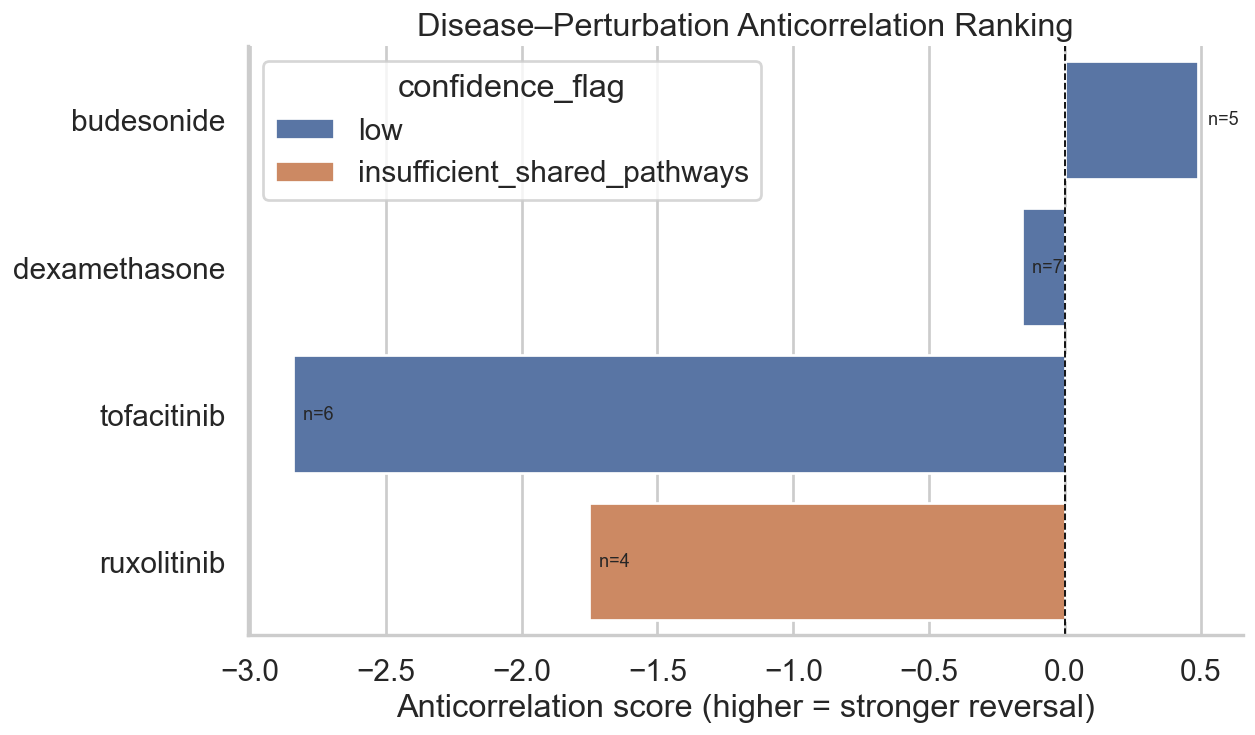

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_anticorrelation_ranking_barplot.png


In [9]:
plot_df = ranking_df.copy()
plot_df["label"] = plot_df["perturbation_name"].fillna(plot_df["perturbation_id"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    y="label",
    x="anticorrelation_score",
    hue="confidence_flag",
    dodge=False,
    ax=ax
)
ax.set_title("Disease–Perturbation Anticorrelation Ranking")
ax.set_xlabel("Anticorrelation score (higher = stronger reversal)")
ax.set_ylabel("")
ax.axvline(0, color="black", linestyle="--", linewidth=1)

for i, row in plot_df.iterrows():
    ax.text(
        row["anticorrelation_score"] if pd.notna(row["anticorrelation_score"]) else 0,
        i,
        f"  n={int(row['n_shared_pathways'])}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
barplot_file = FIGURES_DIR / "final_anticorrelation_ranking_barplot.png"
plt.savefig(barplot_file, bbox_inches="tight")
plt.show()

print("Saved:", barplot_file)

## 9. Figure 2 — Scatter plots for top perturbations

A good reversing perturbation should show a downward trend:
as disease NES increases, perturbation NES tends to decrease.

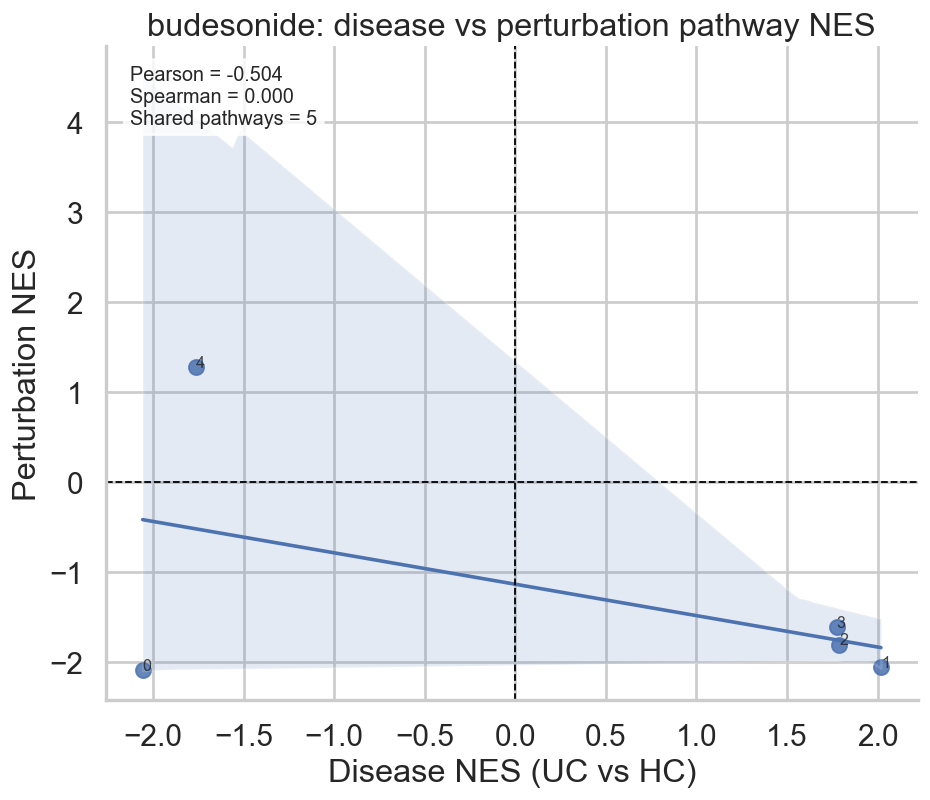

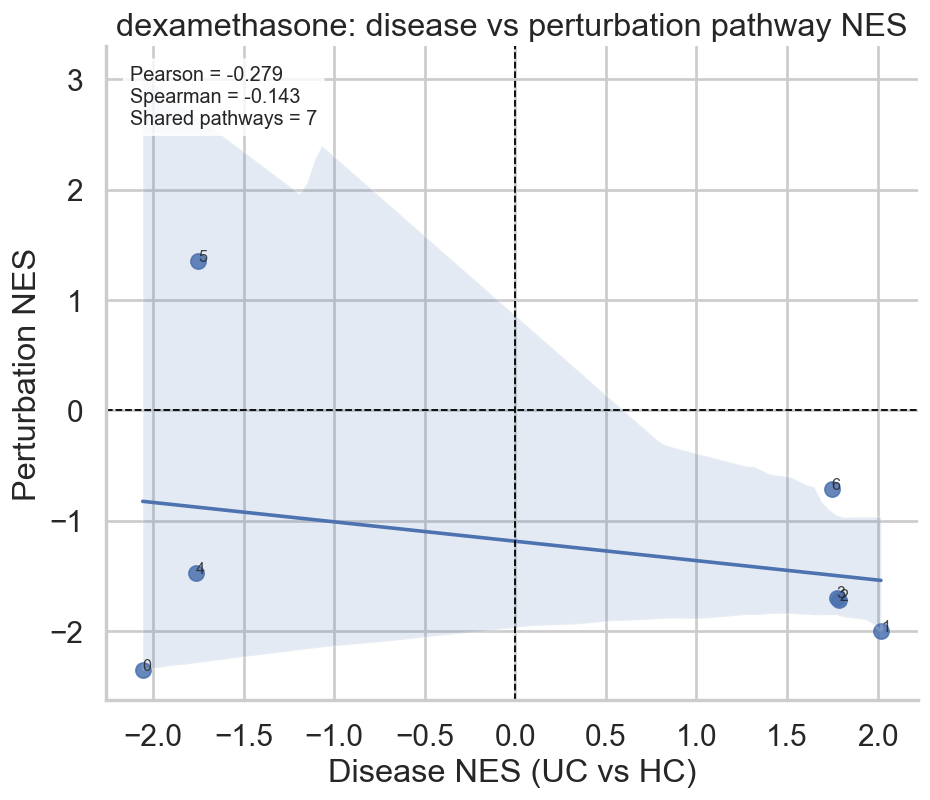

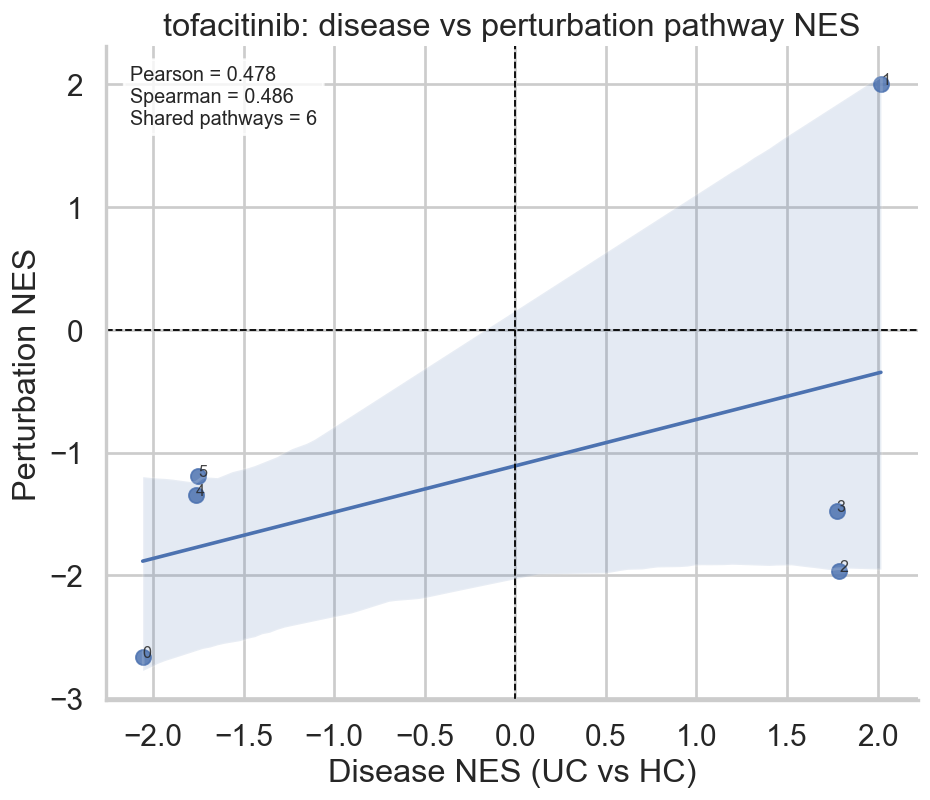

[PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/drug_002_budesonide_disease_vs_perturbation_scatter.png'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/drug_001_dexamethasone_disease_vs_perturbation_scatter.png'),
 PosixPath('/Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/drug_004_tofacitinib_disease_vs_perturbation_scatter.png')]

In [10]:
valid_ranked = ranking_df[ranking_df["valid_for_ranking"]].copy()
top_n = min(3, len(valid_ranked))
top_perturbations = valid_ranked.head(top_n)["perturbation_id"].tolist()

scatter_files = []

for perturbation_id in top_perturbations:
    sub = per_pathway_df[per_pathway_df["perturbation_id"] == perturbation_id].copy()
    if sub.empty:
        continue

    title_name = sub["perturbation_name"].iloc[0]
    pearson_val = ranking_df.loc[ranking_df["perturbation_id"] == perturbation_id, "pearson_corr"].iloc[0]
    spearman_val = ranking_df.loc[ranking_df["perturbation_id"] == perturbation_id, "spearman_corr"].iloc[0]

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    sns.regplot(
        data=sub,
        x="disease_NES",
        y="perturbation_NES",
        scatter_kws={"s": 70, "alpha": 0.85},
        line_kws={"linewidth": 2},
        ax=ax
    )

    # annotate top pathways by absolute disease NES
    annotate_df = sub.nlargest(8, "abs_disease_NES")
    for _, row in annotate_df.iterrows():
        ax.text(
            row["disease_NES"],
            row["perturbation_NES"],
            str(row["Pathway"])[:42],
            fontsize=9,
            alpha=0.85
        )

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{title_name}: disease vs perturbation pathway NES")
    ax.set_xlabel("Disease NES (UC vs HC)")
    ax.set_ylabel("Perturbation NES")
    ax.text(
        0.03, 0.97,
        f"Pearson = {pearson_val:.3f}\nSpearman = {spearman_val:.3f}\nShared pathways = {sub['Pathway'].nunique()}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    outpath = FIGURES_DIR / f"{perturbation_id}_{title_name}_disease_vs_perturbation_scatter.png"
    plt.savefig(outpath, bbox_inches="tight")
    plt.show()
    scatter_files.append(outpath)

scatter_files

## 10. Figure 3 — Heatmap of shared pathway NES for top perturbations

Rows are pathways and columns are top-ranked perturbations.
The disease NES is included as a reference column.

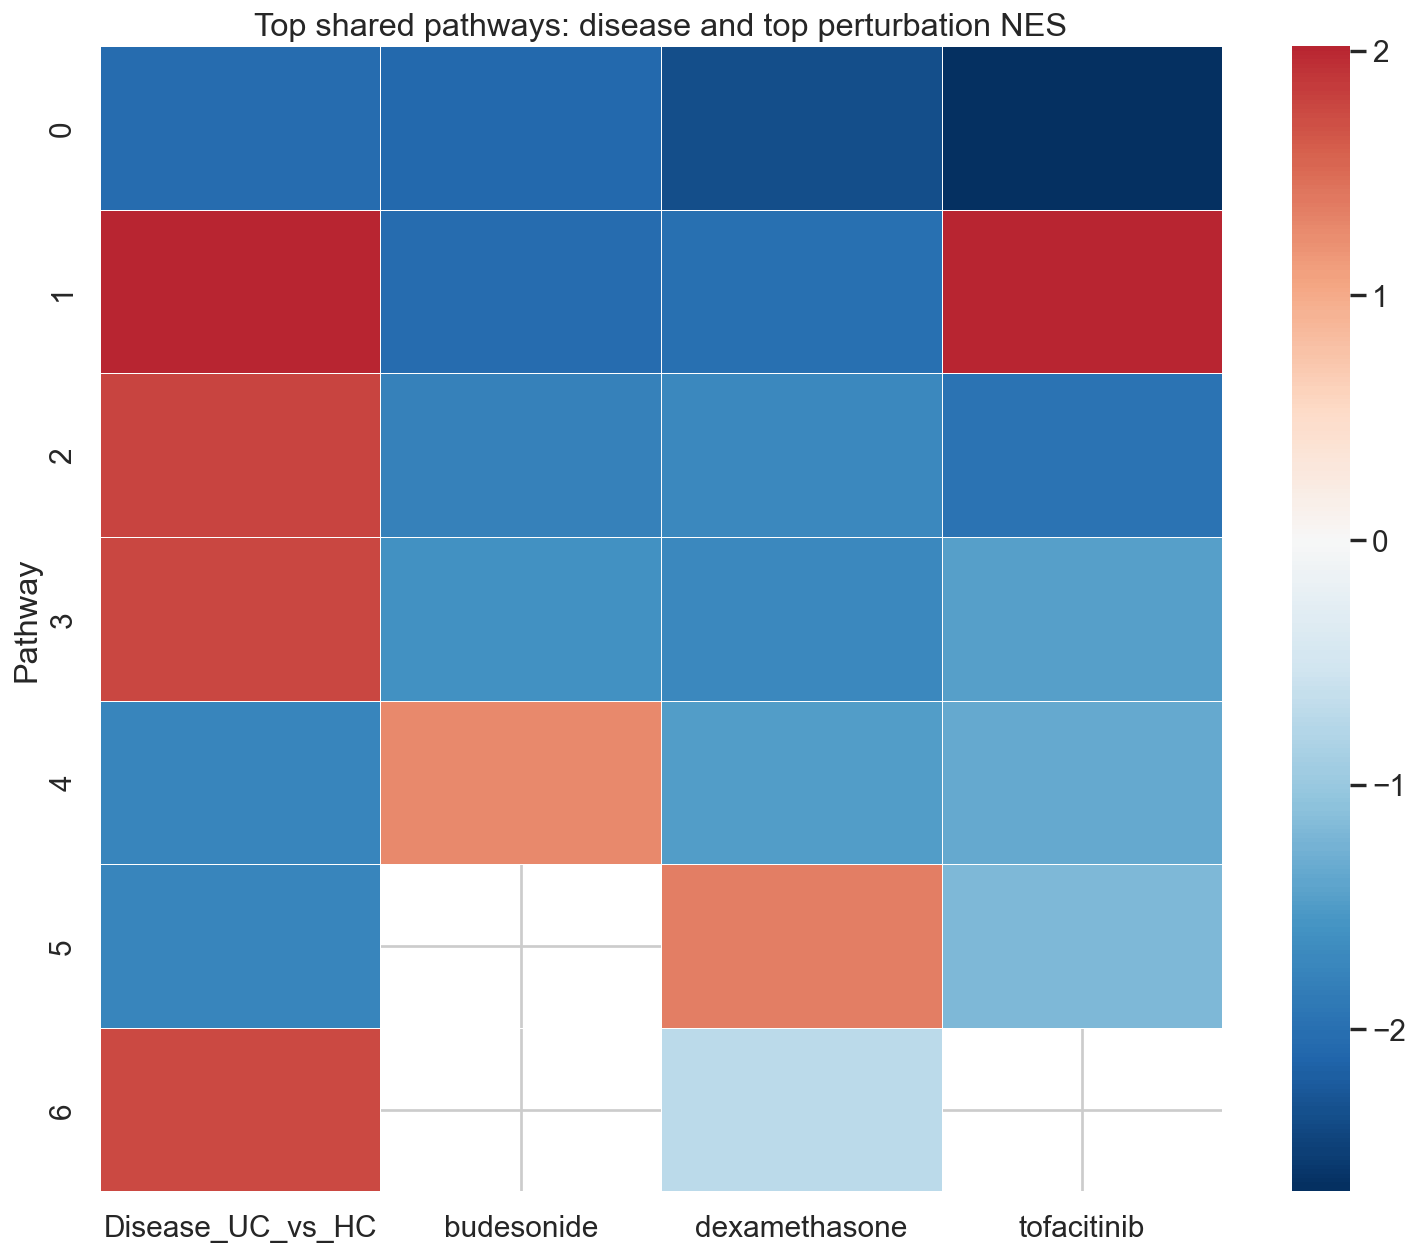

Saved: /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/top_perturbations_shared_pathway_heatmap.png


In [11]:
if len(top_perturbations) > 0:
    top_pathways = (
        per_pathway_df[per_pathway_df["perturbation_id"].isin(top_perturbations)]
        .groupby("Pathway")["abs_disease_NES"]
        .max()
        .sort_values(ascending=False)
        .head(25)
        .index.tolist()
    )

    heat_df = per_pathway_df[
        per_pathway_df["perturbation_id"].isin(top_perturbations) &
        per_pathway_df["Pathway"].isin(top_pathways)
    ].copy()

    heat_pivot = heat_df.pivot_table(
        index="Pathway",
        columns="perturbation_name",
        values="perturbation_NES",
        aggfunc="mean"
    )

    disease_heat = (
        disease_df[disease_df["Pathway"].isin(top_pathways)]
        .set_index("Pathway")[["disease_NES"]]
        .rename(columns={"disease_NES": "Disease_UC_vs_HC"})
    )

    heat_matrix = disease_heat.join(heat_pivot, how="inner")
    heat_matrix = heat_matrix.loc[heat_matrix["Disease_UC_vs_HC"].abs().sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        heat_matrix,
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        linecolor="white",
        ax=ax
    )
    ax.set_title("Top shared pathways: disease and top perturbation NES")
    ax.set_xlabel("")
    ax.set_ylabel("Pathway")

    plt.tight_layout()
    heatmap_file = FIGURES_DIR / "top_perturbations_shared_pathway_heatmap.png"
    plt.savefig(heatmap_file, bbox_inches="tight")
    plt.show()

    print("Saved:", heatmap_file)
else:
    print("No valid perturbations available for heatmap.")

## 11. Figure 4 — Focused inflammatory pathway heatmap

This panel highlights biologically relevant inflammatory Hallmark pathways when they are present.

In [12]:
inflammatory_keywords = [
    "TNFA SIGNALING VIA NFKB",
    "INFLAMMATORY RESPONSE",
    "IL6 JAK STAT3 SIGNALING",
    "INTERFERON GAMMA RESPONSE",
    "INTERFERON ALPHA RESPONSE",
    "COMPLEMENT",
    "APOPTOSIS",
    "HYPOXIA",
    "ALLOGRAFT REJECTION",
    "KRAS SIGNALING",
    "COAGULATION",
]

focus_df = per_pathway_df[
    per_pathway_df["Pathway"].str.upper().isin([x.upper() for x in inflammatory_keywords])
].copy()

if not focus_df.empty and len(top_perturbations) > 0:
    focus_df = focus_df[focus_df["perturbation_id"].isin(top_perturbations)].copy()

    focus_pivot = focus_df.pivot_table(
        index="Pathway",
        columns="perturbation_name",
        values="perturbation_NES",
        aggfunc="mean"
    )

    focus_disease = (
        disease_df[disease_df["Pathway"].isin(focus_pivot.index)]
        .set_index("Pathway")[["disease_NES"]]
        .rename(columns={"disease_NES": "Disease_UC_vs_HC"})
    )

    focus_heat = focus_disease.join(focus_pivot, how="inner")

    if not focus_heat.empty:
        fig, ax = plt.subplots(figsize=(11, max(4, 0.6 * len(focus_heat))))
        sns.heatmap(
            focus_heat,
            cmap="RdBu_r",
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            linecolor="white",
            ax=ax
        )
        ax.set_title("Focused inflammatory pathway reversal heatmap")
        ax.set_xlabel("")
        ax.set_ylabel("Pathway")

        plt.tight_layout()
        focused_heatmap_file = FIGURES_DIR / "focused_inflammatory_pathway_heatmap.png"
        plt.savefig(focused_heatmap_file, bbox_inches="tight")
        plt.show()

        print("Saved:", focused_heatmap_file)
    else:
        print("Focused pathway set became empty after joining disease and perturbation tables.")
else:
    print("No inflammatory Hallmark pathways found in the aligned data.")

No inflammatory Hallmark pathways found in the aligned data.


## 12. Biological interpretation

### What anticorrelation means biologically

If UC disease pathways are enriched in a pro-inflammatory direction, a useful therapeutic perturbation should drive those same pathways in the opposite direction.

Examples:

- **glucocorticoids** such as dexamethasone or budesonide are expected to suppress inflammatory signaling and stress-response programs
- **JAK inhibitors** such as tofacitinib or ruxolitinib are expected to dampen cytokine- and interferon-driven signaling

Therefore, perturbations with **negative correlation** to the disease pathway signature are plausible reversal candidates.

### Why this is scientifically useful

This analysis moves beyond single-gene overlap and asks whether a perturbation reverses the **systems-level pathway state** of disease.

That makes the result easier to explain biologically and easier to validate with additional omics layers later.

### Important limitations

1. The perturbation signatures are **curated and compact**, not full transcriptome-wide LINCS profiles
2. Pathway results depend on the chosen gene set collection  
   Here: **MSigDB Hallmark 2020**
3. Some perturbations may have **few shared pathways**, making ranking less stable
4. Correlation does not prove causality; it is a **prioritization** signal, not final validation
5. Cell context matters: disease tissue and perturbation cell line are not identical systems

### Practical interpretation

In this project, top candidates should ideally show:

- more negative Pearson and Spearman correlations
- high pathway reversal fraction
- adequate shared pathway coverage
- plausible mechanism consistent with UC inflammatory biology

## 13. Optional inspection of top candidate pathway details

In [13]:
if len(valid_ranked) > 0:
    top_id = valid_ranked.iloc[0]["perturbation_id"]
    top_name = valid_ranked.iloc[0]["perturbation_name"]

    top_detail = (
        per_pathway_df[per_pathway_df["perturbation_id"] == top_id]
        .sort_values("pathway_reversal_score_weighted", ascending=False)
        .reset_index(drop=True)
    )

    print(f"Top candidate: {top_name} ({top_id})")
    display(top_detail[[
        "Pathway",
        "disease_NES",
        "perturbation_NES",
        "disease_FDR",
        "perturbation_FDR",
        "reversal",
        "direction_pattern",
        "pathway_reversal_score_weighted"
    ]].head(20))
else:
    print("No valid ranked perturbation available.")

Top candidate: budesonide (drug_002)


,Pathway,disease_NES,perturbation_NES,disease_FDR,perturbation_FDR,reversal,direction_pattern,pathway_reversal_score_weighted
0,1,2.018700,-2.053031,0.000000,NaN,True,disease_up__perturb_down,625.812484
1,4,-1.765320,1.282861,0.000000,NaN,True,disease_down__perturb_up,341.963634
2,2,1.789889,-1.802822,0.003271,NaN,True,disease_up__perturb_down,7.236743
3,3,1.773973,-1.608436,0.002181,NaN,True,disease_up__perturb_down,6.650263
4,0,-2.058361,-2.089488,0.000000,NaN,False,both_down,-649.438726


## 14. Final summary

This notebook produced a **clean disease–perturbation anticorrelation ranking** for UC pathway reversal.

### Final deliverables

- a ranked perturbation table
- a per-pathway interpretation table
- publication-style summary figures
- a transparent, biologically interpretable scoring framework

This is suitable as a **flagship portfolio notebook** because it demonstrates:

- reproducible pathway-level analysis
- robust handling of imperfect perturbation data
- mechanistic interpretation
- clear candidate prioritization logic

In [14]:
print("Final output files:")
for path in [
    ranking_outfile,
    per_pathway_outfile,
    barplot_file if 'barplot_file' in globals() else None,
    heatmap_file if 'heatmap_file' in globals() else None,
    focused_heatmap_file if 'focused_heatmap_file' in globals() else None,
]:
    if path is not None:
        print("-", path)

Final output files:
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_ranking.tsv
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/tables/final_anticorrelation_per_pathway_details.tsv
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/final_anticorrelation_ranking_barplot.png
- /Users/vaibhav.mh/protein_repos/multiomics-perturbation-target-discovery/results/figures/top_perturbations_shared_pathway_heatmap.png
